In [1]:
# st_lgcp_pyro.py
# Spatio-temporal Log-Gaussian Cox Process (LGCP) with sparse variational GP in Pyro.
# - latent f(s,t) ~ GP(0, K), K = K_space + K_periodic_time + sigma_noise^2 I
# - log intensity: log lambda = alpha + beta * plankton + f(s,t)
# - counts y ~ Poisson(exp(log lambda))
#
# Variational approximation:
# q(u) = N(m, S) on inducing outputs u at inducing inputs Z (space-time)
# f ≈ K_fu K_uu^{-1} u (conditional mean) + diag-noise via covariance approx
# ELBO ≈ E_{q(u)}[log p(y | f(u))] - KL(q(u) || p(u))
#
# This file simulates data and fits the model with stochastic gradient descent.

import math
import random
import argparse
import numpy as np
import torch
import torch.linalg as tla
import pyro
import pyro.distributions as dist
from pyro.optim import Adam
import matplotlib.pyplot as plt
import torch.nn as nn

pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float32)

# -------------------------
# Kernel utilities
# -------------------------
def rbf_kernel(x, y, lengthscale, variance):
    # x: [N, D], y: [M, D] -> returns [N, M]
    # squared euclidean distance
    x2 = (x**2).sum(dim=1, keepdim=True) # [N,1]
    y2 = (y**2).sum(dim=1, keepdim=True) # [M,1]
    d2 = x2 + y2.t() - 2.0 * (x @ y.t())
    l2 = lengthscale**2
    K = variance * torch.exp(-0.5 * d2 / l2)
    return K

def periodic_kernel_1d(t1, t2, period, lengthscale, variance):
    # t1: [N,1], t2: [M,1] -> returns [N,M]
    # k(t,t') = variance * exp( - 2 sin^2(pi|t-t'|/period) / ell^2 )
    diff = (t1 - t2.t()).abs()
    arg = torch.sin(math.pi * diff / period)
    K = variance * torch.exp(-2.0 * (arg**2) / (lengthscale**2))
    return K

# -------------------------
# Simulate dataset
# -------------------------
def simulate_data(grid_x=50, grid_y=50, T=5, seed=0):
    """
    Simulate plankton covariate and counts on a grid over time.
    Returns:
      coords: [N, 3] where columns = x, y, t (t normalized to [0,1])
      plankton: [N] binary or float covariate
      y: [N] integer counts
      meta: dictionary with grid shapes and date indices
    """
    rng = np.random.default_rng(seed)
    xs = np.linspace(0.0, 1.0, grid_x)
    ys = np.linspace(0.0, 1.0, grid_y)
    # Create grid of spatial coordinates
    Xs, Ys = np.meshgrid(xs, ys, indexing="xy") # shape (grid_y, grid_x)
    coords_list = []
    plank_list = []
    t_list = []
    for ti in range(T):
        tnorm = ti / max(1, T-1) # normalize to [0,1]
        # simulate plankton presence as a smooth spatial field (random bump)
        plank_field = np.exp(-((Xs-0.3)**2 + (Ys-0.6)**2)/(0.02 + 0.1*rng.random()))
        # Add some noise and threshold
        plank_field = plank_field + 0.2 * rng.normal(size=plank_field.shape)
        plank_field = (plank_field - plank_field.min()) / (plank_field.max() - plank_field.min())
        # flatten
        coords_here = np.column_stack((Xs.ravel(), Ys.ravel(), np.full(Xs.size, tnorm)))
        coords_list.append(coords_here)
        plank_list.append(plank_field.ravel())
        t_list.append(np.full(Xs.size, ti))
    coords = np.vstack(coords_list) # [N,3]
    plankton = np.concatenate(plank_list) # [N]
    times = np.concatenate(t_list) # integer time indices if needed

    # simulate latent GP surface f(s,t): use separable K_space + K_periodic_time
    device = torch.device("cpu")
    X = torch.tensor(coords, dtype=torch.get_default_dtype(), device=device) # [N,3]
    N = X.shape[0]
    # simple kernel hyperparameters (true)
    spatial_length = 0.12
    spatial_var = 1.2
    time_period = 1.0 # period in normalized time units (since T small, periodic effect across T)
    time_length = 0.05
    time_var = 0.8
    noise_var = 0.05

    # compute spatial K (use only x,y columns)
    X_space = X[:, 0:2]
    K_space = rbf_kernel(X_space, X_space, spatial_length, spatial_var)
    tvec = X[:, 2:3]
    K_time = periodic_kernel_1d(tvec, tvec, period=time_period, lengthscale=time_length, variance=time_var)
    K = K_space + K_time + noise_var * torch.eye(N)
    # draw latent f ~ N(0,K)
    L = torch.linalg.cholesky(K + 1e-5 * torch.eye(N))
    f = (L @ torch.randn(N)).numpy()
    # construct log-intensity with covariate effect
    alpha = -1.0
    beta = 2.0 # effect of plankton
    log_lambda = alpha + beta * plankton + f
    lam = np.exp(log_lambda)
    # simulate Poisson counts
    y = rng.poisson(lam.clip(max=20.0)) # clip to avoid enormous counts in simulation
    # return everything as numpy arrays
    meta = {"grid_x": grid_x, "grid_y": grid_y, "T": T, "N": N}
    return coords, plankton.astype(np.float32), y.astype(np.int32), meta

# -------------------------
# Sparse variational GP components
# -------------------------
def initialize_inducing_points(coords, M=200, seed=0):
    rng = np.random.default_rng(seed)
    N = coords.shape[0]
    idx = rng.choice(N, size=M, replace=False)
    Z = torch.tensor(coords[idx], dtype=torch.get_default_dtype()) # [M,3]
    return Z

def build_Kuu(Z, kern_params):
    # Z [M,3] -> use spatial RBF on first 2 cols + periodic on time col, sum them
    Z_space = Z[:, 0:2]
    Z_time = Z[:, 2:3]
    K_s = rbf_kernel(Z_space, Z_space, kern_params["spatial_length"], kern_params["spatial_var"])
    K_t = periodic_kernel_1d(Z_time, Z_time, kern_params["time_period"], kern_params["time_length"], kern_params["time_var"])
    Kuu = K_s + K_t + (kern_params["jitter"] + kern_params.get("noise_var", 1e-6)) * torch.eye(Z.shape[0])
    return Kuu

def build_Kfu(X, Z, kern_params):
    # X [N,3], Z [M,3] -> returns [N,M]
    X_space = X[:, 0:2]
    Z_space = Z[:, 0:2]
    X_time = X[:, 2:3]
    Z_time = Z[:, 2:3]
    Ks = rbf_kernel(X_space, Z_space, kern_params["spatial_length"], kern_params["spatial_var"])
    Kt = periodic_kernel_1d(X_time, Z_time, kern_params["time_period"], kern_params["time_length"], kern_params["time_var"])
    Kfu = Ks + Kt
    return Kfu

# KL between q(u)=N(m,S) and p(u)=N(0,K)
def kl_qp(m, S, K):
    # m: [M], S: [M,M] cov, K: [M,M] prior cov
    M = m.shape[0]
    # we'll compute using standard formula: 0.5*( tr(K^{-1} S) + m^T K^{-1} m - M + logdet(K) - logdet(S) )
    cholK = torch.linalg.cholesky(K + 1e-6 * torch.eye(K.shape[0]))
    Kinv_m = torch.cholesky_solve(m.unsqueeze(-1), cholK).squeeze(-1)
    trace_term = torch.trace(torch.cholesky_solve(S, cholK))
    logdetK = 2.0 * torch.log(torch.diagonal(cholK)).sum()
    cholS = torch.linalg.cholesky(S + 1e-6 * torch.eye(S.shape[0]))
    logdetS = 2.0 * torch.log(torch.diagonal(cholS)).sum()
    mKm = (m * Kinv_m).sum()
    kl = 0.5 * (trace_term + mKm - M + logdetK - logdetS)
    return kl

# -------------------------
# Model & variational objective
# -------------------------
class SparseLGCP(nn.Module):
    def __init__(self, coords_np, plankton_np, y_np, M_inducing=200, device="cpu"):
        super().__init__()
        # coords_np: [N,3] numpy
        self.device = torch.device(device)
        self.X = torch.tensor(coords_np, dtype=torch.get_default_dtype(), device=self.device) # [N,3]
        self.plank = torch.tensor(plankton_np, dtype=torch.get_default_dtype(), device=self.device) # [N]
        self.y = torch.tensor(y_np, dtype=torch.get_default_dtype(), device=self.device) # [N]
        self.N = self.X.shape[0]
        # initialize kernel hyperparams (log-transformed for positivity)
        self.log_spatial_length = torch.nn.Parameter(torch.tensor(math.log(0.2), device=self.device))
        self.log_spatial_var = torch.nn.Parameter(torch.tensor(math.log(1.0), device=self.device))
        self.log_time_length = torch.nn.Parameter(torch.tensor(math.log(0.1), device=self.device))
        self.log_time_var = torch.nn.Parameter(torch.tensor(math.log(0.8), device=self.device))
        # period is positive but we keep it unconstrained param in log-space too
        self.log_time_period = torch.nn.Parameter(torch.tensor(math.log(1.0), device=self.device))
        # jitter / white-noise variance
        self.log_noise = torch.nn.Parameter(torch.tensor(math.log(1e-3), device=self.device))
        # linear covariate coeff and intercept
        self.alpha = torch.nn.Parameter(torch.tensor(-1.0, device=self.device))
        self.beta = torch.nn.Parameter(torch.tensor(1.0, device=self.device))
        # inducing points
        self.M = min(M_inducing, max(10, int(0.05 * self.N))) # cap M to reasonable fraction
        Z_init = initialize_inducing_points(coords_np, M=self.M, seed=1)
        self.Z = torch.nn.Parameter(Z_init.to(self.device)) # [M,3]
        # variational parameters for q(u): mean m [M], lower-triangular L params for S = L L^T
        self.m = torch.nn.Parameter(torch.zeros(self.M, device=self.device))
        # parametrize L as unconstrained lower-tri matrix entries; we'll build positive-def S
        # initialize L as small diagonal
        L_init = 0.01 * torch.eye(self.M, device=self.device)
        self.L_unconstrained = torch.nn.Parameter(L_init) # shape [M,M]


    def kernel_params(self):
        return {
            "spatial_length": torch.exp(self.log_spatial_length),
            "spatial_var": torch.exp(self.log_spatial_var),
            "time_length": torch.exp(self.log_time_length),
            "time_var": torch.exp(self.log_time_var),
            "time_period": torch.exp(self.log_time_period),
            "jitter": 1e-6,
            "noise_var": torch.exp(self.log_noise),
        }

    def get_S_from_L(self):
        # ensure positive-def S = L L^T; L_unconstrained is lower-tri, but for stability symmetrize
        L = torch.tril(self.L_unconstrained)
        S = L @ L.t()
        # add tiny diagonal for numeric
        S = S + 1e-6 * torch.eye(self.M, device=self.device)
        return S

    def elbo_mc(self, num_mc=4, minibatch_size=None):
        """
        Monte Carlo estimate of ELBO:
         E_{q(u)}[log p(y|f(u))] - KL(q||p)
        We sample u ~ q(u) (num_mc samples), compute f_mean = Kfu Kuu^{-1} u for all data points,
        compute Poisson log-likelihood and average.
        minibatch_size: if not None, use random minibatches of data to scale to large N.
        """
        kern = self.kernel_params()
        Z = self.Z # [M,3]
        Kuu = build_Kuu(Z, kern) # [M,M]
        # precompute inverse via cholesky
        jitter = 1e-6
        jitter_eye = jitter * torch.eye(self.M, device=self.device)
        cholKuu = torch.linalg.cholesky(Kuu + jitter_eye)
        Kuu_inv_matsolve = lambda B: torch.cholesky_solve(B, cholKuu) # solves Kuu x = B

        # compute KL
        S = self.get_S_from_L() # [M,M]
        kl = kl_qp(self.m, S, Kuu)

        # data minibatching
        if minibatch_size is None or minibatch_size >= self.N:
            idx = torch.arange(self.N, device=self.device)
            n_batch = self.N
        else:
            idx = torch.randperm(self.N, device=self.device)[:minibatch_size]
            n_batch = idx.shape[0]

        X_batch = self.X[idx, :] # [n_batch,3]
        plank_batch = self.plank[idx]
        y_batch = self.y[idx]

        # compute Kfu for batch: [n_batch, M]
        Kfu = build_Kfu(X_batch, Z, kern)

        # precompute A = Kfu @ Kuu^{-1} -> shape [n_batch, M]
        Kuu_inv = Kuu_inv_matsolve(torch.eye(self.M, device=self.device))
        A = Kfu @ Kuu_inv # [n_batch, M]

        # sample u ~ q(u) = N(m, S)
        Lq = torch.linalg.cholesky(S + 1e-6 * torch.eye(self.M, device=self.device))
        elbo_ll = 0.0
        for _ in range(num_mc):
            eps = torch.randn(self.M, device=self.device)
            u_sample = self.m + Lq @ eps # [M]
            # compute f_mean for batch: A @ u_sample (shape [n_batch])
            f_mean = A @ u_sample
            # approximate marginal variance at f: diag( Kff - A Kfu^T + A S A^T ) ignored here for simplicity
            # so we plug f_mean into Poisson likelihood (this is standard mean-field-style approx)
            log_rate = self.alpha + self.beta * plank_batch + f_mean
            rate = torch.exp(log_rate)
            # log p(y|rate) for Poisson (no factorial term needed for optimization)
            logp = (y_batch * torch.log(rate + 1e-9) - rate).sum()
            elbo_ll += logp / num_mc

        # scale minibatch
        scale = float(self.N) / float(n_batch)
        elbo = scale * elbo_ll - kl
        # we return negative elbo as loss to minimize
        return elbo, {"elbo_ll": elbo_ll.item(), "kl": kl.item(), "scale": scale}

    def predict_rate(self, coords_new_np, plank_new_np, num_samples=200):
        """
        Predict posterior mean rate at new inputs using current variational q(u).
        Uses the conditional mean E[f|u] with u ~ q(u); Monte Carlo average.
        coords_new_np: [Nnew,3] numpy
        plank_new_np: [Nnew] numpy
        """
        Xnew = torch.tensor(coords_new_np, dtype=torch.get_default_dtype(), device=self.device)
        plank = torch.tensor(plank_new_np, dtype=torch.get_default_dtype(), device=self.device)
        kern = self.kernel_params()
        Z = self.Z
        Kuu = build_Kuu(Z, kern)
        cholKuu = torch.linalg.cholesky(Kuu + 1e-6 * torch.eye(self.M, device=self.device))
        Kuu_inv = lambda B: torch.cholesky_solve(B, cholKuu)
        Kfu_new = build_Kfu(Xnew, Z, kern) # [Nnew, M]
        Kuu_inv_eye = Kuu_inv(torch.eye(self.M, device=self.device))
        A_new = Kfu_new @ Kuu_inv_eye # [Nnew, M]
        # sample from q(u) and compute rates
        S = self.get_S_from_L()
        Lq = torch.linalg.cholesky(S + 1e-6 * torch.eye(self.M, device=self.device))
        rates_acc = torch.zeros((num_samples, Xnew.shape[0]), device=self.device)
        for s in range(num_samples):
            eps = torch.randn(self.M, device=self.device)
            u = self.m + Lq @ eps
            f_mean = A_new @ u
            log_rate = self.alpha + self.beta * plank + f_mean
            rates_acc[s] = torch.exp(log_rate)
        rate_mean = rates_acc.mean(dim=0).cpu().detach().numpy()
        rate_p05 = torch.quantile(rates_acc, 0.05, dim=0).cpu().detach().numpy()
        rate_p95 = torch.quantile(rates_acc, 0.95, dim=0).cpu().detach().numpy()
        return rate_mean, rate_p05, rate_p95

# -------------------------
# Training loop
# -------------------------
def train_model(coords, plankton, y, M=200, lr=1e-2, num_steps=1000, minibatch=None):
    model = SparseLGCP(coords, plankton, y, M_inducing=M, device="cpu")
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    losses = []
    for step in range(1, num_steps+1):
        optimizer.zero_grad()
        elbo, info = model.elbo_mc(num_mc=3, minibatch_size=minibatch)
        loss = -elbo # minimize negative ELBO
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if step % 100 == 0 or step == 1:
            print(f"[{step}/{num_steps}] -loss={loss.item():.3f} (ll_est={info['elbo_ll']:.3f} kl={info['kl']:.3f} scale={info['scale']:.1f})")
    return model, losses



/home/samuele/miniconda3/envs/nemoai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gridx = 50
gridy = 50
T = 5
M = 200
steps = 800
lr = 0.01
print("Simulating data...")
coords, plankton, y, meta = simulate_data(grid_x=gridx, grid_y=gridy, T=T, seed=0)
print("N = ", meta["N"], "grid:", meta["grid_x"], meta["grid_y"], "T:", meta["T"])
# Fit model


Simulating data...
N =  12500 grid: 50 50 T: 5


Training sparse variational LGCP...
[1/800] -loss=18681.916 (ll_est=-2938.650 kl=315.351 scale=6.2)
[100/800] -loss=58978.020 (ll_est=-7544.222 kl=11826.634 scale=6.2)
[200/800] -loss=18022.828 (ll_est=-1461.008 kl=8891.528 scale=6.2)
[300/800] -loss=10097.900 (ll_est=-532.288 kl=6771.101 scale=6.2)
[400/800] -loss=3339.061 (ll_est=166.972 kl=4382.636 scale=6.2)
[500/800] -loss=4342.164 (ll_est=-149.964 kl=3404.888 scale=6.2)
[600/800] -loss=11229.919 (ll_est=-1229.482 kl=3545.657 scale=6.2)
[700/800] -loss=989.096 (ll_est=244.896 kl=2519.695 scale=6.2)
[800/800] -loss=-3343.819 (ll_est=848.520 kl=1959.434 scale=6.2)


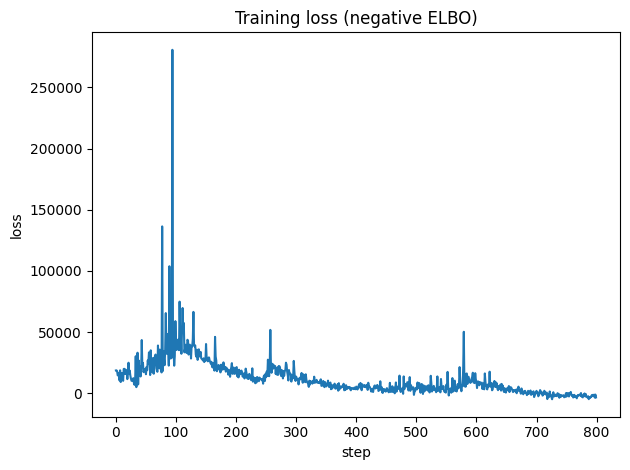

Making posterior predictions for last time slice (N_last= 2500 )


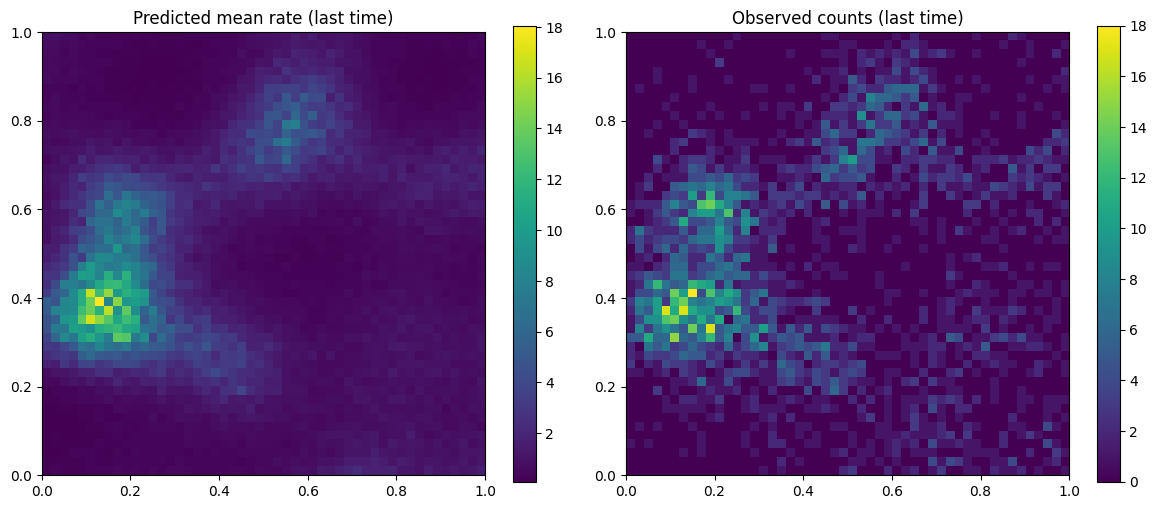

Inferred kernel params (approx):
spatial_length=0.180, spatial_var=0.928
time_length=0.116, time_var=0.451, time_period=1.054
alpha=-0.615, beta=1.769


In [3]:
print("Training sparse variational LGCP...")
model, losses = train_model(coords, plankton, y, M=M, lr=lr, num_steps=steps, minibatch=2000)

# Plot loss
plt.figure()
plt.plot(losses)
plt.title("Training loss (negative ELBO)")
plt.xlabel("step")
plt.ylabel("loss")
plt.tight_layout()
plt.show()

# Predict rate on the training grid for time t=last time slice
# e.g. predict positions at time T-1
T = meta["T"]
# pick points with time == last time index
idx_last = np.where(np.isclose(coords[:,2], (T-1)/max(1, T-1)))[0]
coords_last = coords[idx_last]
plank_last = plankton[idx_last]
print("Making posterior predictions for last time slice (N_last=", coords_last.shape[0],")")
rate_mean, rate_p05, rate_p95 = model.predict_rate(coords_last, plank_last, num_samples=200)

# reshape to grid and plot heatmap of mean rate and observed counts
gx = meta["grid_x"]
gy = meta["grid_y"]
# order: we used meshgrid with Xs, Ys indexing='xy' then ravel -> shape (gy*gx,)
mean_grid = rate_mean.reshape((gy, gx))
obs_grid = y[idx_last].reshape((gy, gx))

fig, axs = plt.subplots(1,2,figsize=(12,5))
im0 = axs[0].imshow(mean_grid, origin='lower', extent=(0,1,0,1))
axs[0].set_title("Predicted mean rate (last time)")
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(obs_grid, origin='lower', extent=(0,1,0,1))
axs[1].set_title("Observed counts (last time)")
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()
plt.show()

# Print a small summary of inferred hyperparams
kp = model.kernel_params()
print("Inferred kernel params (approx):")
print(f"spatial_length={kp['spatial_length'].item():.3f}, spatial_var={kp['spatial_var'].item():.3f}")
print(f"time_length={kp['time_length'].item():.3f}, time_var={kp['time_var'].item():.3f}, time_period={kp['time_period'].item():.3f}")
print(f"alpha={model.alpha.item():.3f}, beta={model.beta.item():.3f}")

## Now consider a synthetic dataset that emulates sharks movement near the plancton zone

In [4]:
def simulate_sharks_with_plankton(grid_x=50, grid_y=50, T=5, N_sharks=50, seed=0):
    """
    Simulate moving plankton and shark positions influenced by it.
    Returns:
      coords: [N, 3] (x, y, t_norm)
      plankton: [N] float covariate (normalized density per cell)
      y: [N] integer counts (number of sharks per cell)
      meta: dict with grid info
    """
    rng = np.random.default_rng(seed)
    xs = np.linspace(0.0, 1.0, grid_x)
    ys = np.linspace(0.0, 1.0, grid_y)
    Xs, Ys = np.meshgrid(xs, ys, indexing="xy") # (grid_y, grid_x)

    coords_list, plank_list, y_list = [], [], []

    # inizializza plancton come una macchia
    px, py = rng.integers(0, grid_x), rng.integers(0, grid_y)

    # posizioni iniziali squali (in coordinate di cella, non normalizzate)
    sharks = np.stack([
        rng.integers(0, grid_x, size=N_sharks),
        rng.integers(0, grid_y, size=N_sharks)
    ], axis=1)

    for ti in range(T):
        tnorm = ti / max(1, T-1)

        # --- aggiorna plancton ---
        px = (px + rng.integers(-1, 2)) % grid_x
        py = (py + rng.integers(-1, 2)) % grid_y
        plank_field = np.exp(-((Xs-xs[px])**2 + (Ys-ys[py])**2)/0.01)
        plank_field = (plank_field - plank_field.min()) / (plank_field.max() - plank_field.min())

        # --- muovi squali ---
        new_sharks = []
        for sx, sy in sharks:
            if rng.random() < 0.7:
                # si muove verso la cella vicina col massimo plancton
                best = plank_field[sy, sx]
                best_pos = (sx, sy)
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        nx, ny = (sx+dx) % grid_x, (sy+dy) % grid_y
                        if plank_field[ny, nx] > best:
                            best = plank_field[ny, nx]
                            best_pos = (nx, ny)
                new_sharks.append(best_pos)
            else:
                # random walk
                nx = (sx + rng.choice([-1, 0, 1])) % grid_x
                ny = (sy + rng.choice([-1, 0, 1])) % grid_y
                new_sharks.append((nx, ny))
        sharks = np.array(new_sharks)

        # conteggio squali per cella
        counts = np.zeros((grid_y, grid_x), dtype=int)
        for sx, sy in sharks:
            counts[sy, sx] += 1

        # --- prepara output ---
        coords_here = np.column_stack((Xs.ravel(), Ys.ravel(), np.full(Xs.size, tnorm)))
        coords_list.append(coords_here)
        plank_list.append(plank_field.ravel())
        y_list.append(counts.ravel())

    coords = np.vstack(coords_list)
    plankton = np.concatenate(plank_list).astype(np.float32)
    y = np.concatenate(y_list).astype(np.int32)
    meta = {"grid_x": grid_x, "grid_y": grid_y, "T": T, "N": coords.shape[0]}

    return coords, plankton, y, meta

In [5]:
gridx = 50
gridy = 50
T = 5
M = 200
steps = 800
lr = 0.01
print("Simulating data...")
coords, plankton, y, meta = simulate_data(grid_x=gridx, grid_y=gridy, T=T, seed=0)
print("N = ", meta["N"], "grid:", meta["grid_x"], meta["grid_y"], "T:", meta["T"])
# Fit model


Simulating data...
N =  12500 grid: 50 50 T: 5


Training sparse variational LGCP...
[1/800] -loss=15381.713 (ll_est=-2410.618 kl=315.351 scale=6.2)
[100/800] -loss=22089.449 (ll_est=-2719.418 kl=5093.085 scale=6.2)
[200/800] -loss=18517.328 (ll_est=-1954.571 kl=6301.261 scale=6.2)
[300/800] -loss=14454.481 (ll_est=-1629.907 kl=4267.562 scale=6.2)
[400/800] -loss=8755.225 (ll_est=-945.765 kl=2844.195 scale=6.2)
[500/800] -loss=4683.512 (ll_est=-413.504 kl=2099.110 scale=6.2)
[600/800] -loss=5833.645 (ll_est=-666.442 kl=1668.384 scale=6.2)
[700/800] -loss=4875.390 (ll_est=-560.550 kl=1371.949 scale=6.2)
[800/800] -loss=4350.350 (ll_est=-510.291 kl=1161.031 scale=6.2)


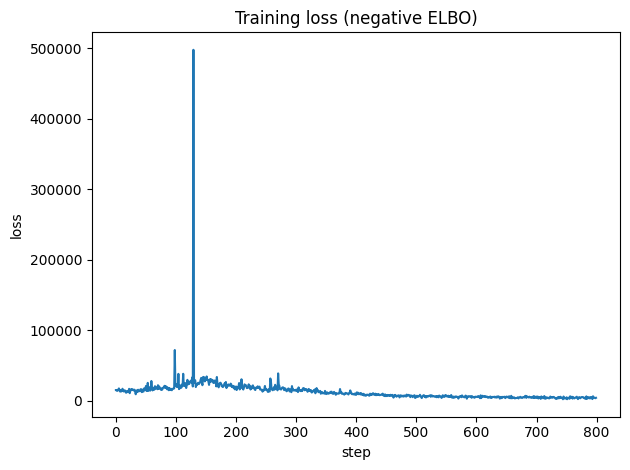

Making posterior predictions for last time slice (N_last= 2500 )


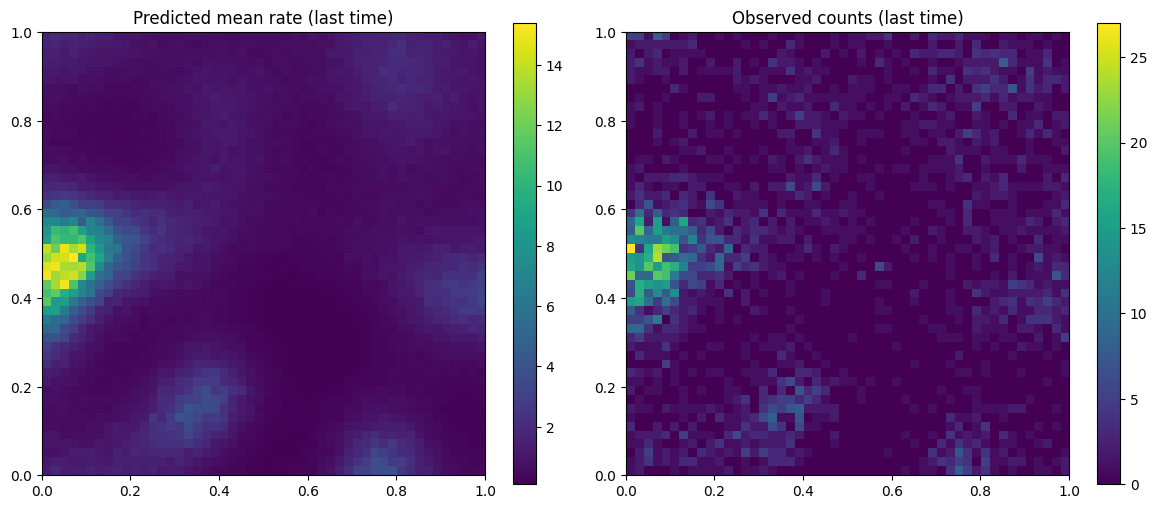

Inferred kernel params (approx):
spatial_length=0.167, spatial_var=0.975
time_length=0.147, time_var=0.410, time_period=0.862
alpha=-1.054, beta=1.088


In [6]:
print("Training sparse variational LGCP...")
model, losses = train_model(coords, plankton, y, M=M, lr=lr, num_steps=steps, minibatch=2000)

# Plot loss
plt.figure()
plt.plot(losses)
plt.title("Training loss (negative ELBO)")
plt.xlabel("step")
plt.ylabel("loss")
plt.tight_layout()
plt.show()

# Predict rate on the training grid for time t=last time slice
# e.g. predict positions at time T-1
T = meta["T"]
# pick points with time == last time index
idx_last = np.where(np.isclose(coords[:,2], (T-1)/max(1, T-1)))[0]
coords_last = coords[idx_last]
plank_last = plankton[idx_last]
print("Making posterior predictions for last time slice (N_last=", coords_last.shape[0],")")
rate_mean, rate_p05, rate_p95 = model.predict_rate(coords_last, plank_last, num_samples=200)

# reshape to grid and plot heatmap of mean rate and observed counts
gx = meta["grid_x"]
gy = meta["grid_y"]
# order: we used meshgrid with Xs, Ys indexing='xy' then ravel -> shape (gy*gx,)
mean_grid = rate_mean.reshape((gy, gx))
obs_grid = y[idx_last].reshape((gy, gx))

fig, axs = plt.subplots(1,2,figsize=(12,5))
im0 = axs[0].imshow(mean_grid, origin='lower', extent=(0,1,0,1))
axs[0].set_title("Predicted mean rate (last time)")
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(obs_grid, origin='lower', extent=(0,1,0,1))
axs[1].set_title("Observed counts (last time)")
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()
plt.show()

# Print a small summary of inferred hyperparams
kp = model.kernel_params()
print("Inferred kernel params (approx):")
print(f"spatial_length={kp['spatial_length'].item():.3f}, spatial_var={kp['spatial_var'].item():.3f}")
print(f"time_length={kp['time_length'].item():.3f}, time_var={kp['time_var'].item():.3f}, time_period={kp['time_period'].item():.3f}")
print(f"alpha={model.alpha.item():.3f}, beta={model.beta.item():.3f}")